<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/RICS_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

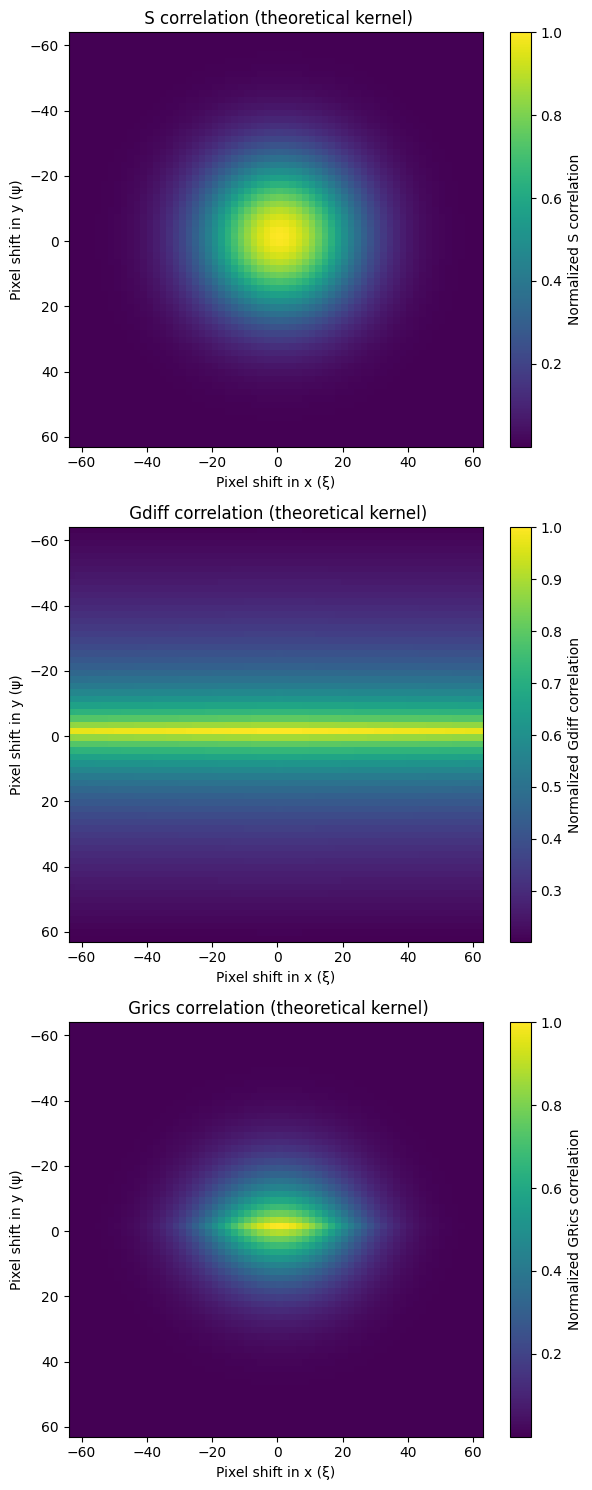

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# RICS correlation map simulation
# ------------------------------
# This script provides two ways to simulate a RICS map:
# 1) A fast, pedagogical/theoretical kernel based on raster timing + diffusion (recommended)
# 2) An optional particle-based Monte Carlo (slower), commented out by default
# The output figures are saved as PNG files in the working directory.

# ------------------------------
# Parameters
# ------------------------------
Nx, Ny = 128, 128            # image size (pixels)
pixel_size_um = 0.05          # pixel size (micrometers)

tau_p = 20e-6                # pixel dwell time (seconds)
line_retrace = 200e-6        # line retrace time (seconds)
T_line = Nx * tau_p + line_retrace  # time between the start of consecutive lines (s)

D = 1                    # diffusion coefficient (um^2/s), typical for proteins
w_psf_um = 0.3               # PSF (Gaussian) lateral width (um), ~0.3 um for confocal
N_molecules = 10.0           # effective number (controls amplitude)

# ------------------------------
# 1) Theoretical/fast RICS kernel
# ------------------------------
# RICS concept: G(xi, psi) = S(xi, psi) * G_diff(Delta t)
# where Delta t = xi * tau_p + psi * T_line encodes raster timing.
# S(xi, psi) is the PSF autocorrelation (Gaussian here),
# and G_diff is a simple exponential decay with correlation time tau_D ~ w_psf^2/(4D)

xi = np.arange(-Nx//2, Nx//2)
psi = np.arange(-Ny//2, Ny//2)
XI, PSI = np.meshgrid(xi, psi, indexing='xy')

# Spatial term: PSF autocorrelation (Gaussian)
# Autocorrelation width is sqrt(2) * w_psf; using a Gaussian form in pixel units
w_pix = w_psf_um / pixel_size_um
S = np.exp(-(XI**2 + PSI**2) / (2 * (np.sqrt(2) * w_pix)**2))

# Temporal term: simple exponential decay of correlation with time delay
# A common heuristic is tau_D ~ w_psf^2 / (4D) for diffusion in a Gaussian detection volume
# (pedagogical; not a full confocal model)
Tau_D = (w_psf_um**2) / (4 * D)
Delta_t = np.abs(XI) * tau_p + np.abs(PSI) * T_line
G_diff = 1/(1+Delta_t / Tau_D)

# Combine terms and normalize by N
G_rics = (1.0 / N_molecules) * S * G_diff

# Normalize so that G(0,0)=1 for visualization
G_rics /= G_rics[Ny//2, Nx//2]

# ------------------------------
# Plot and save the theoretical RICS map
# ------------------------------
Size_Map = G_rics.shape[0]
F,A = plt.subplots(3,1,figsize=(6,15))

#plt.imshow(G_rics[int(Size_Map//2 * 0.8)+1:int(Size_Map//2 * 1.2)+1,int(Size_Map//2 * 0.8):int(Size_Map//2 * 1.2)], extent=[xi[0], xi[-1], psi[-1], psi[0]], cmap='viridis')
I0 = A[0].imshow(S[int(Size_Map//2 * 0.5)+1:int(Size_Map//2 * 1.5)+1,int(Size_Map//2 * 0.5):int(Size_Map//2 * 1.5)], extent=[xi[0], xi[-1], psi[-1], psi[0]], cmap='viridis')
plt.colorbar(I0,ax=A[0],label='Normalized S correlation')
A[0].set_title(' S correlation (theoretical kernel)')
A[0].set_xlabel('Pixel shift in x (ξ)')
A[0].set_ylabel('Pixel shift in y (ψ)')

I1 = A[1].imshow(G_diff[int(Size_Map//2 * 0.5)+1:int(Size_Map//2 * 1.5)+1,int(Size_Map//2 * 0.5):int(Size_Map//2 * 1.5)], extent=[xi[0], xi[-1], psi[-1], psi[0]], cmap='viridis')
plt.colorbar(I1,ax=A[1],label='Normalized Gdiff correlation')
A[1].set_title(' Gdiff correlation (theoretical kernel)')
A[1].set_xlabel('Pixel shift in x (ξ)')
A[1].set_ylabel('Pixel shift in y (ψ)')

I2 = A[2].imshow(G_rics[int(Size_Map//2 * 0.5)+1:int(Size_Map//2 * 1.5)+1,int(Size_Map//2 * 0.5):int(Size_Map//2 * 1.5)], extent=[xi[0], xi[-1], psi[-1], psi[0]], cmap='viridis')
plt.colorbar(I2,ax=A[2],label='Normalized GRics correlation')
A[2].set_title(' Grics correlation (theoretical kernel)')
A[2].set_xlabel('Pixel shift in x (ξ)')
A[2].set_ylabel('Pixel shift in y (ψ)')

plt.tight_layout()
plt.show()

plt.savefig('rics_correlation_theoretical.png', dpi=200)
plt.close()

# ------------------------------
# 2) Optional particle-based Monte Carlo (slow) -- simplified
# ------------------------------
# We simulate a single frame with raster timing sampling diffusing particles,
# compute δI, and obtain the 2D spatial autocorrelation via FFT.
# This is a simplified delta-PSF model (binning particles into pixels).

